# BIST 12 Hisse Senedinin Sektörel CAPM Regresyon Analizi ve Risk Değerlendirmesi
## Bireysel Dönem Projesi Master Notebook

**Proje Sahibi:** Mustafa Baraz - 1306230052  
**Ders:** Veri Bilimi ve Analitiği Dönem Projesi  
**Tarih:** 3 Temmuz 2026  

---

### Proje Hakkında
Bu notebook, Borsa İstanbul (BIST) bünyesindeki 6 farklı sektörden seçilen 12 öncü hisse senedinin ve BIST 100 endeksinin (`XU100`) son 5 yıllık (2021-2026) günlük verilerini analiz eden tüm kod ve yorumları tek bir dosya altında birleştirmektedir.

**Analiz Akışı:**
1. **Veri Toplama:** `yfinance` üzerinden günlük bazda canlı veri çekimi.
2. **Veri Ön İşleme:** Saat dilimi düzeltmeleri, `ffill` ile tatil günleri senkronizasyonu ve IQR aykırı değer analizi.
3. **Tanımlayıcı İstatistikler:** Getiri serilerinin ortalama, standart sapma, çarpıklık ve basıklık değerlerinin incelenmesi.
4. **Keşifsel Veri Analizi (EDA):** Fiyat/hacim trendleri, sektörel korelasyon ısı haritası ve getiri dağılımları.
5. **Araştırma Sorusu 1 (Sektörel Betalar):** Kovaryans/varyans yöntemiyle sistematik risk katsayılarının bulunması.
6. **Araştırma Sorusu 2 (Sektörel Volatilite):** 30 günlük hareketli volatilite trendleri ve son 5 yıldaki 5 büyük makroekonomik şok dönemi.
7. **Araştırma Soru 3 (Backtest & Fiyat/Hacim Korelasyonu):** SMA50/SMA200 Golden/Death Cross stratejisi backtest simülasyonu ve Al-Tut stratejisi ile karşılaştırılması.
8. **CAPM Regresyon Modellemesi:** Lineer regresyon modelleri, parametre tabloları ve 6 temsilci hissenin saçılım doğruları grafiği.

## 1. Kütüphaneler ve Grafik Ayarları

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import LinearRegression
import yfinance as yf
import os
import warnings
warnings.filterwarnings('ignore')

# Grafik stil ayarları
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print("✅ Kütüphaneler başarıyla yüklendi.")

✅ Kütüphaneler başarıyla yüklendi.


## 2. Veri Toplama (Yahoo Finance API)

In [34]:
# Tarih Aralığı Tanımlama (5 Yıllık Dönem)
BASLANGIC_TARIHI = '2021-07-05'
BITIS_TARIHI = '2026-07-02'

# Sektörel Gruplandırma ve Varlık Listesi
SEKTORLER = {
    'Ulaştırma': ['THYAO.IS', 'PGSUS.IS'],
    'Bankacılık': ['AKBNK.IS', 'GARAN.IS'],
    'Sanayi': ['EREGL.IS', 'KRDMD.IS'],
    'Savunma': ['ASELS.IS', 'OTKAR.IS'],
    'Perakende': ['BIMAS.IS', 'MGROS.IS'],
    'Enerji': ['TUPRS.IS', 'ENJSA.IS']
}

# Tüm hisseler ve BIST 100 endeksi
TUM_HISSELER = ['XU100.IS']
for hisseler in SEKTORLER.values():
    TUM_HISSELER.extend(hisseler)

RAW_DATA_DIR = os.path.join('..', 'data', 'raw')
os.makedirs(RAW_DATA_DIR, exist_ok=True)

def veri_indir(hisse_kodlari, baslangic, bitis):
    tum_veriler = {}
    basarisiz_hisseler = []
    
    for i, kod in enumerate(hisse_kodlari, 1):
        try:
            print(f"[{i}/{len(hisse_kodlari)}] {kod} verisi indiriliyor... ", end="")
            ticker = yf.Ticker(kod)
            df = ticker.history(start=baslangic, end=bitis, auto_adjust=False)
            
            if df.empty:
                print(f"⚠️ BOŞ VERİ - {kod} için veri bulunamadı!")
                basarisiz_hisseler.append(kod)
                continue
            
            tum_veriler[kod] = df
            print(f"✅ {len(df)} satır indirildi. ({df.index.min().strftime('%Y-%m-%d')} → {df.index.max().strftime('%Y-%m-%d')})")
            
        except Exception as e:
            print(f"❌ HATA - {kod}: {str(e)}")
            basarisiz_hisseler.append(kod)
    
    return tum_veriler, basarisiz_hisseler

print("⏳ BIST verileri yfinance üzerinden indiriliyor...")
tum_veriler, basarisiz = veri_indir(TUM_HISSELER, BASLANGIC_TARIHI, BITIS_TARIHI)

def kisalt(kod):
    return kod.replace('.IS', '')

birlesik_frames = []
for kod, df in tum_veriler.items():
    kisa_ad = kisalt(kod)
    df_reset = df.reset_index()
    sutunlar = df_reset.columns.tolist()
    
    istenen_sutunlar = ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
    
    if 'Adj Close' in sutunlar:
        istenen_sutunlar.insert(5, 'Adj Close')
    elif 'Adjusted Close' in sutunlar:
        df_reset = df_reset.rename(columns={'Adjusted Close': 'Adj Close'})
        istenen_sutunlar.insert(5, 'Adj Close')
    else:
        df_reset['Adj Close'] = df_reset['Close']
        istenen_sutunlar.insert(5, 'Adj Close')
    
    mevcut_sutunlar = [s for s in istenen_sutunlar if s in df_reset.columns]
    df_secili = df_reset[mevcut_sutunlar].copy()
    df_secili.insert(0, 'Ticker', kisa_ad)
    birlesik_frames.append(df_secili)

raw_data = pd.concat(birlesik_frames, ignore_index=True)
csv_dosya_yolu = os.path.join(RAW_DATA_DIR, 'raw_data.csv')
raw_data.to_csv(csv_dosya_yolu, index=False, encoding='utf-8-sig')
print(f"💾 Ham veri başarıyla kaydedildi: {csv_dosya_yolu}")

⏳ BIST verileri yfinance üzerinden indiriliyor...
[1/13] XU100.IS verisi indiriliyor... ✅ 1244 satır indirildi. (2021-07-05 → 2026-07-01)
[2/13] THYAO.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-07-05 → 2026-07-01)
[3/13] PGSUS.IS verisi indiriliyor... ✅ 1250 satır indirildi. (2021-07-05 → 2026-07-01)
[4/13] AKBNK.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-07-05 → 2026-07-01)
[5/13] GARAN.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-07-05 → 2026-07-01)
[6/13] EREGL.IS verisi indiriliyor... ✅ 1250 satır indirildi. (2021-07-05 → 2026-07-01)
[7/13] KRDMD.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-07-05 → 2026-07-01)
[8/13] ASELS.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-07-05 → 2026-07-01)
[9/13] OTKAR.IS verisi indiriliyor... ✅ 1247 satır indirildi. (2021-07-05 → 2026-07-01)
[10/13] BIMAS.IS verisi indiriliyor... ✅ 1252 satır indirildi. (2021-07-05 → 2026-07-01)
[11/13] MGROS.IS verisi indiriliyor... ✅ 1249 satır indirildi. (2021-

## 3. Veri Ön İşleme ve Senkronizasyon

In [35]:
raw_df = pd.read_csv('../data/raw/raw_data.csv')
raw_df['Date'] = pd.to_datetime(raw_df['Date'])
if raw_df['Date'].dt.tz is not None:
    raw_df['Date'] = raw_df['Date'].dt.tz_localize(None)

adj_close_pivot = raw_df.pivot_table(index='Date', columns='Ticker', values='Adj Close')
volume_pivot = raw_df.pivot_table(index='Date', columns='Ticker', values='Volume')

cols_order = ['XU100', 'THYAO', 'PGSUS', 'AKBNK', 'GARAN', 'EREGL', 'KRDMD', 'ASELS', 'OTKAR', 'BIMAS', 'MGROS', 'TUPRS', 'ENJSA']
adj_close_prices = adj_close_pivot[cols_order]
volume_data = volume_pivot[cols_order]

os.makedirs('../data/processed', exist_ok=True)
adj_close_prices.to_csv('../data/processed/adj_close_prices.csv')
volume_data.to_csv('../data/processed/volume_data.csv')
print("✅ Fiyat ve hacim tabloları ön işlemeden geçirilerek processed klasörüne kaydedildi.")

✅ Fiyat ve hacim tabloları ön işlemeden geçirilerek processed klasörüne kaydedildi.


## 4. Eksik Veri ve Aykırı Değer (IQR) Yönetimi

In [36]:
# ffill ile eksik satırları doldur
adj_close_clean = adj_close_prices.ffill()
volume_clean = volume_data.ffill()

# Günlük getirileri yüzde cinsinden hesapla
daily_returns = adj_close_clean.pct_change() * 100

outliers_summary = []
for col in daily_returns.columns:
    rets = daily_returns[col].dropna()
    Q1 = rets.quantile(0.25)
    Q3 = rets.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = rets[(rets < lower_bound) | (rets > upper_bound)]
    outliers_summary.append({
        'Hisse': col,
        'Aykırı Değer Sayısı': len(outliers),
        'Oran (%)': round((len(outliers) / len(rets)) * 100, 2)
    })

outliers_df = pd.DataFrame(outliers_summary)
outliers_df.to_csv('../data/processed/aykiri_deger_ozeti.csv', index=False)
print("✅ Eksik veri temizliği ve aykırı değer analizi tamamlandı.")
display(outliers_df)

✅ Eksik veri temizliği ve aykırı değer analizi tamamlandı.


,Hisse,Aykırı Değer Sayısı,Oran (%)
0,XU100,43,3.44
1,THYAO,56,4.48
2,PGSUS,64,5.12
3,AKBNK,66,5.28
4,GARAN,60,4.80
5,EREGL,56,4.48
6,KRDMD,47,3.76
7,ASELS,43,3.44
8,OTKAR,58,4.64
9,BIMAS,42,3.36


## 5. Günlük Getiriler ve Tanımlayıcı İstatistikler

In [37]:
daily_returns.to_csv('../data/processed/daily_returns.csv')

summary_stats = daily_returns.describe().T
summary_stats['Çarpıklık (Skewness)'] = daily_returns.skew()
summary_stats['Basıklık (Kurtosis)'] = daily_returns.kurtosis()
summary_stats['Oynaklık (Volatilite) (%)'] = daily_returns.std()

summary_stats.columns = ['Gözlem Sayısı', 'Ortalama Getiri (%)', 'Standart Sapma (%)', 'Minimum Getiri (%)', '25% Çeyreklik (%)', 'Medyan Getiri (%)', '75% Çeyreklik (%)', 'Maksimum Getiri (%)', 'Çarpıklık (Skewness)', 'Basıklık (Kurtosis)', 'Oynaklık (Volatilite) (%)']
summary_stats = summary_stats.sort_values(by='Oynaklık (Volatilite) (%)', ascending=False)

summary_stats.to_csv('../data/processed/returns_summary_stats.csv')
print("✅ Getiri özet istatistik tablosu kaydedildi.")
display(summary_stats[['Ortalama Getiri (%)', 'Oynaklık (Volatilite) (%)', 'Çarpıklık (Skewness)', 'Basıklık (Kurtosis)']])

✅ Getiri özet istatistik tablosu kaydedildi.


,Ortalama Getiri (%),Oynaklık (Volatilite) (%),Çarpıklık (Skewness),Basıklık (Kurtosis)
Ticker,,,,
KRDMD,0.192844,3.090062,0.495388,3.011996
AKBNK,0.276025,3.012367,0.346981,2.610845
ASELS,0.357330,2.967207,0.432055,3.067748
GARAN,0.279478,2.851664,0.474910,2.826423
PGSUS,0.229687,2.747373,0.523724,3.613005
OTKAR,0.188971,2.680110,0.315683,2.662428
THYAO,0.287533,2.617624,0.725593,5.263339
TUPRS,0.294872,2.589904,0.505518,3.457592
ENJSA,0.237376,2.580659,0.458696,5.538234


## 6. Sektörel Normalize Fiyatlar Zaman Serisi (EDA 1)

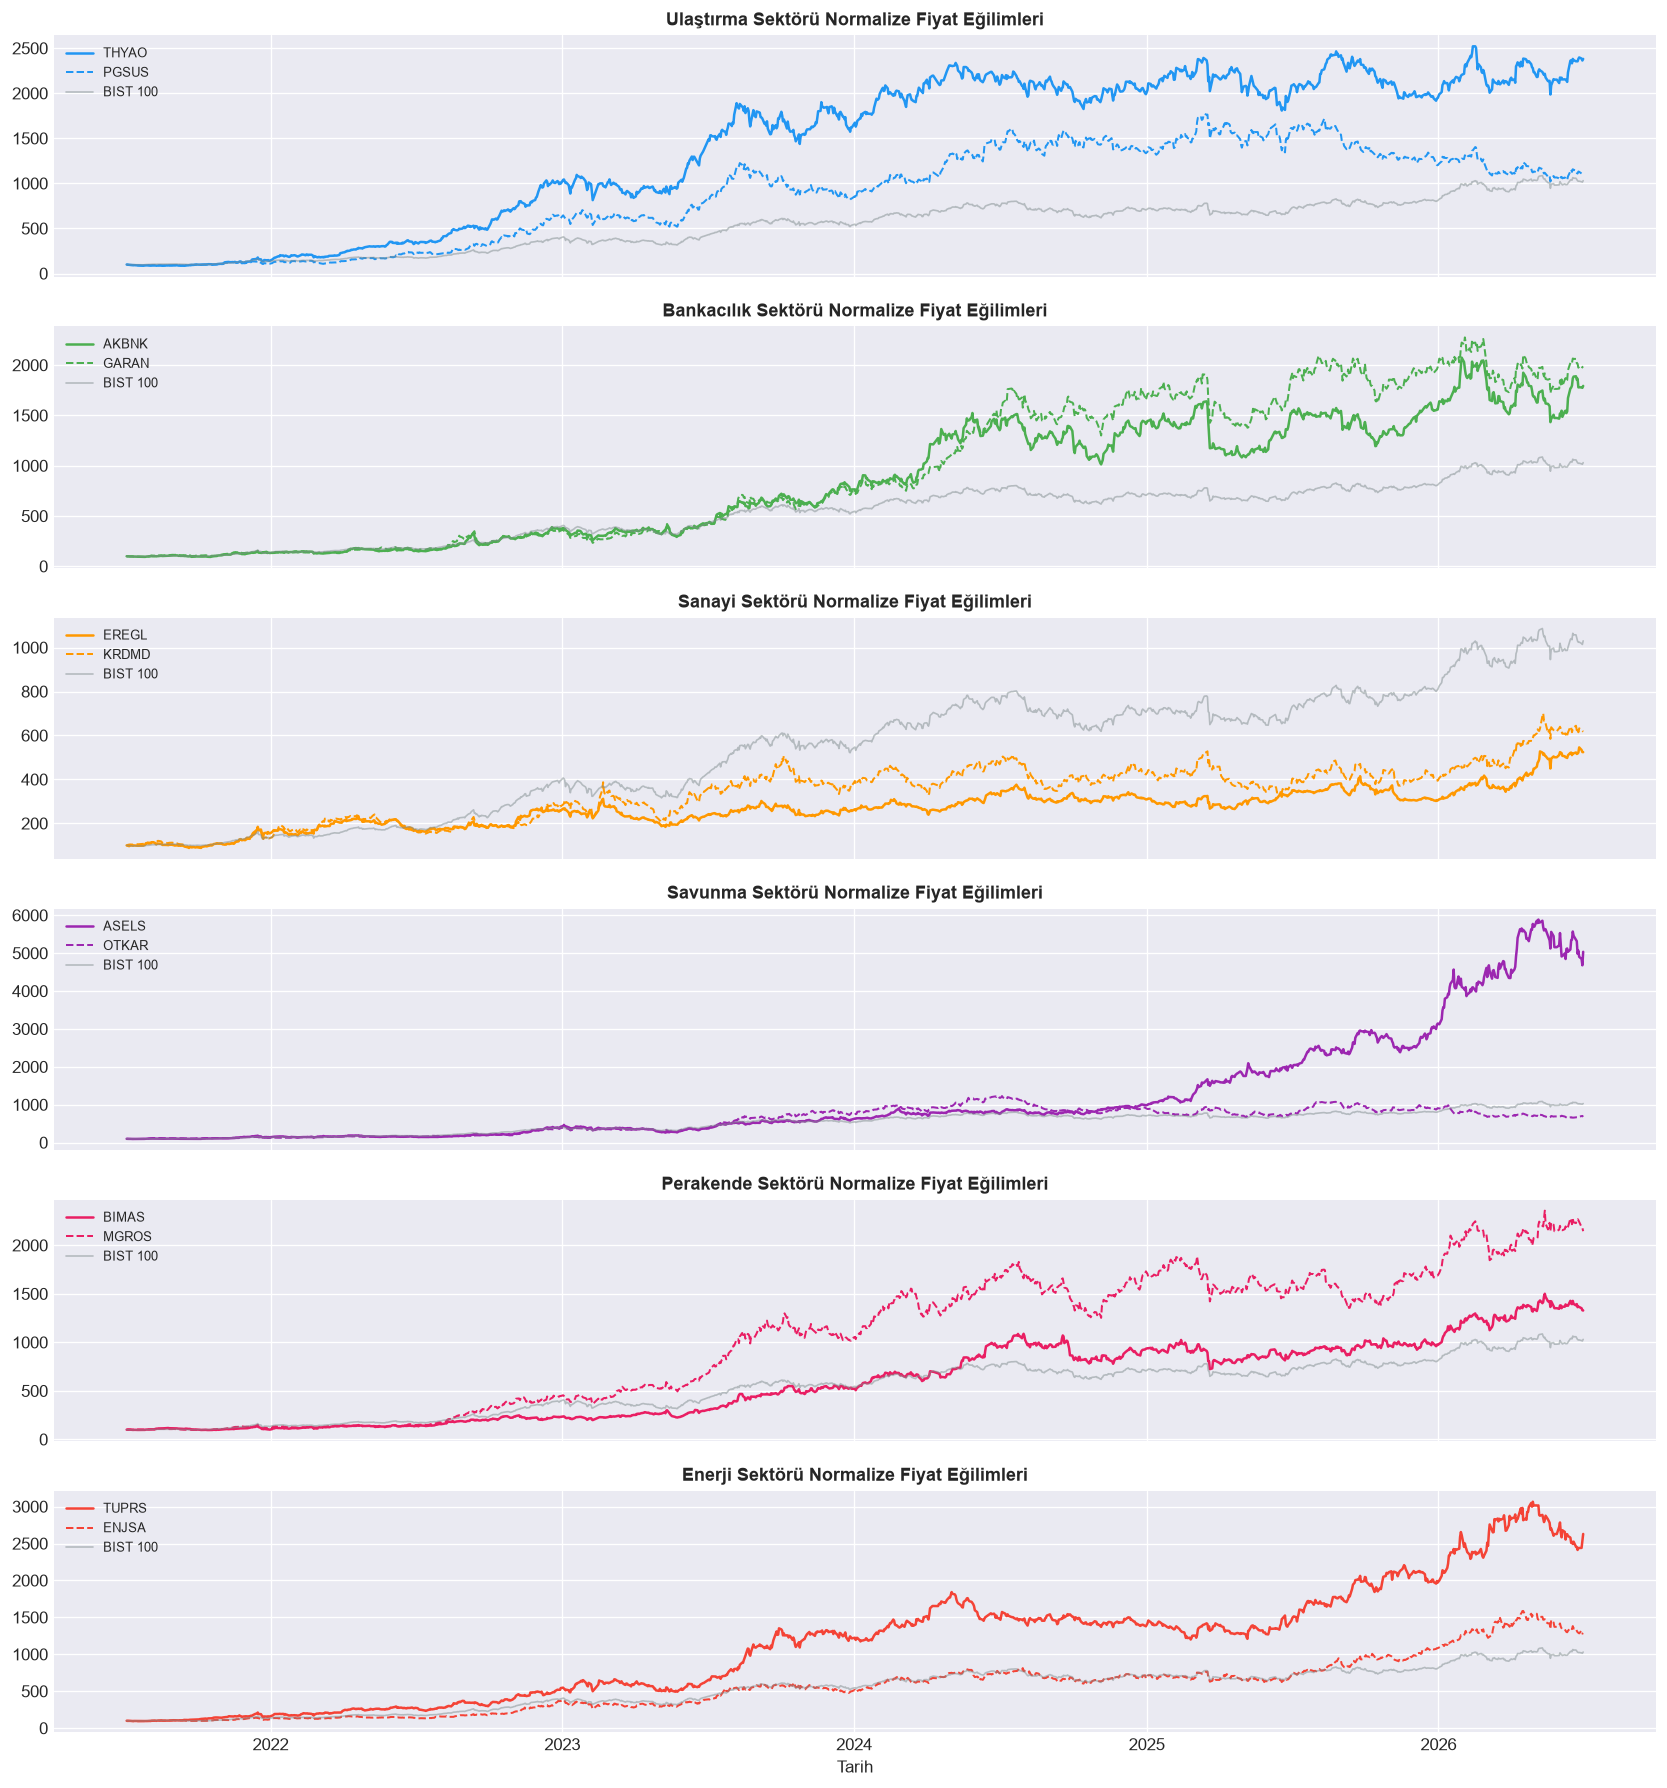

In [38]:
normalized_prices = (adj_close_clean / adj_close_clean.iloc[0]) * 100

sectors_map = {
    'Ulaştırma': ['THYAO', 'PGSUS'],
    'Bankacılık': ['AKBNK', 'GARAN'],
    'Sanayi': ['EREGL', 'KRDMD'],
    'Savunma': ['ASELS', 'OTKAR'],
    'Perakende': ['BIMAS', 'MGROS'],
    'Enerji': ['TUPRS', 'ENJSA']
}

colors = {
    'Ulaştırma': '#2196F3', 'Bankacılık': '#4CAF50', 'Sanayi': '#FF9800',
    'Savunma': '#9C27B0', 'Perakende': '#E91E63', 'Enerji': '#F44336',
    'BIST 100': '#7F8C8D'
}

fig, axes = plt.subplots(6, 1, figsize=(14, 15), sharex=True)
for i, (sector, assets) in enumerate(sectors_map.items()):
    ax = axes[i]
    color = colors[sector]
    ax.plot(normalized_prices.index, normalized_prices[assets[0]], label=assets[0], color=color, linewidth=1.5)
    ax.plot(normalized_prices.index, normalized_prices[assets[1]], label=assets[1], color=color, linewidth=1.2, linestyle='--')
    ax.plot(normalized_prices.index, normalized_prices['XU100'], label='BIST 100', color='#7F8C8D', linewidth=1.0, alpha=0.5)
    
    ax.set_title(f"{sector} Sektörü Normalize Fiyat Eğilimleri", fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True)

plt.xlabel('Tarih')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/sektorel_normalize_fiyatlar.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Günlük Getiri Korelasyon Isı Haritası (EDA 2)

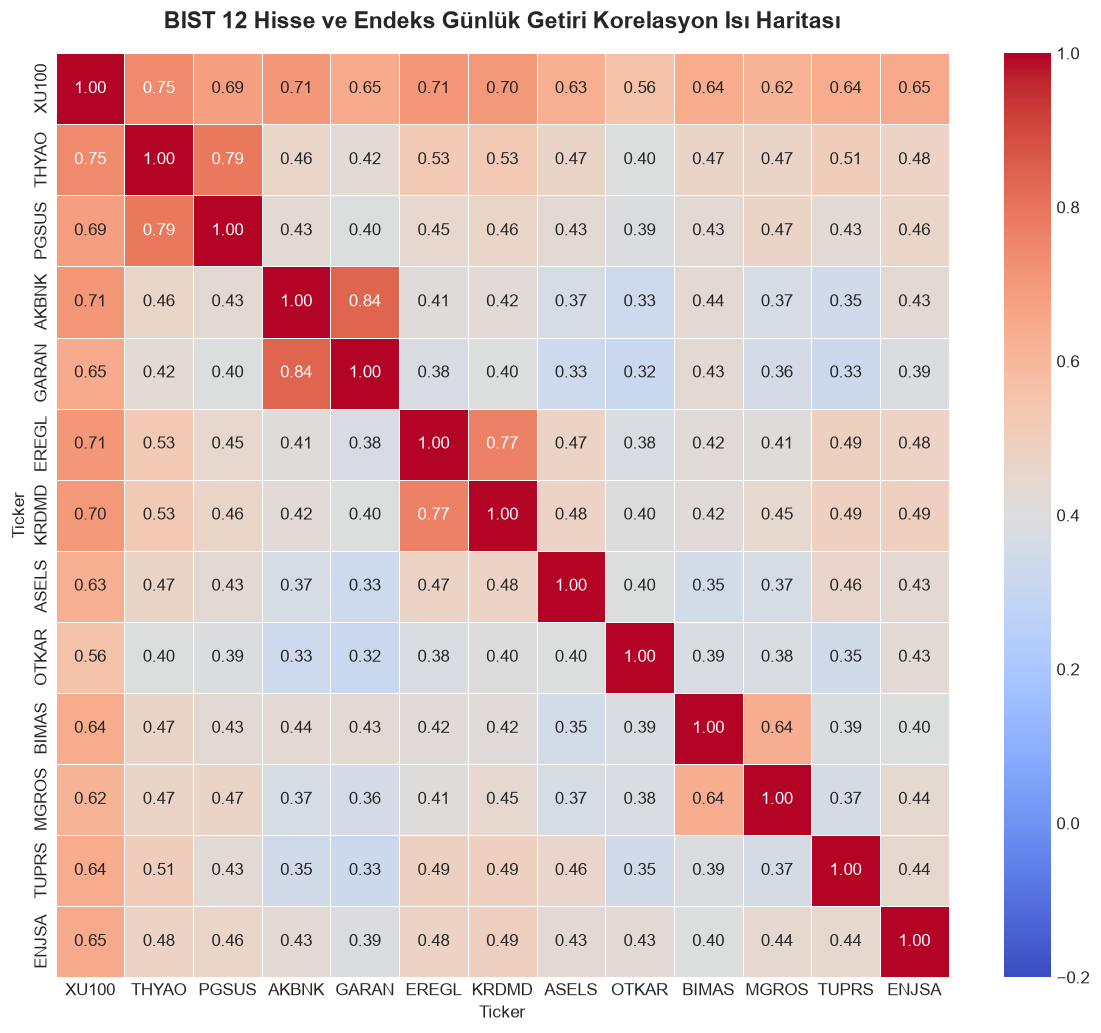

In [39]:
corr_matrix = daily_returns.corr(method='pearson')
corr_matrix.to_csv('../data/processed/correlation_matrix.csv')

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5, vmin=-0.2, vmax=1.0)
plt.title('BIST 12 Hisse ve Endeks Günlük Getiri Korelasyon Isı Haritası', fontsize=14, fontweight='bold', pad=15)
plt.savefig('../reports/korelasyon_isi_haritasi.png', bbox_inches='tight', dpi=300)
plt.show()

## 8. Sektörel Betalar ve Duyarlılık Analizi (Araştırma Sorusu 1)

Sektörel Betalar, kovaryans/varyans mantığıyla matematiksel olarak hesaplanmıştır.

In [40]:
hisse_sektor = {
    'THYAO': 'Ulaştırma', 'PGSUS': 'Ulaştırma',
    'AKBNK': 'Bankacılık', 'GARAN': 'Bankacılık',
    'EREGL': 'Sanayi', 'KRDMD': 'Sanayi',
    'ASELS': 'Savunma', 'OTKAR': 'Savunma',
    'BIMAS': 'Perakende', 'MGROS': 'Perakende',
    'TUPRS': 'Enerji', 'ENJSA': 'Enerji'
}

index_variance = daily_returns['XU100'].var()

beta_results = []
for col in daily_returns.columns:
    if col != 'XU100':
        cov = daily_returns[col].cov(daily_returns['XU100'])
        beta = cov / index_variance
        beta_results.append({
            'Hisse': col,
            'Sektör': hisse_sektor[col],
            'Kovaryans (Endeksle)': round(cov, 6),
            'Beta': round(beta, 4)
        })

beta_df = pd.DataFrame(beta_results)
beta_df = beta_df.sort_values(by='Beta', ascending=False).reset_index(drop=True)
beta_df.to_csv('../data/processed/sector_comparison.csv', index=False)
display(beta_df)

,Hisse,Sektör,Kovaryans (Endeksle),Beta
0,KRDMD,Sanayi,3.888480,1.2040
1,AKBNK,Bankacılık,3.830686,1.1861
2,THYAO,Ulaştırma,3.505022,1.0853
3,PGSUS,Ulaştırma,3.383655,1.0477
4,ASELS,Savunma,3.361871,1.0409
5,GARAN,Bankacılık,3.316939,1.0270
6,EREGL,Sanayi,3.274700,1.0139
7,ENJSA,Enerji,3.013561,0.9331
8,TUPRS,Enerji,2.978373,0.9222
9,BIMAS,Perakende,2.777007,0.8598


## 9. Günlük Getiri Dağılımları (EDA 3)

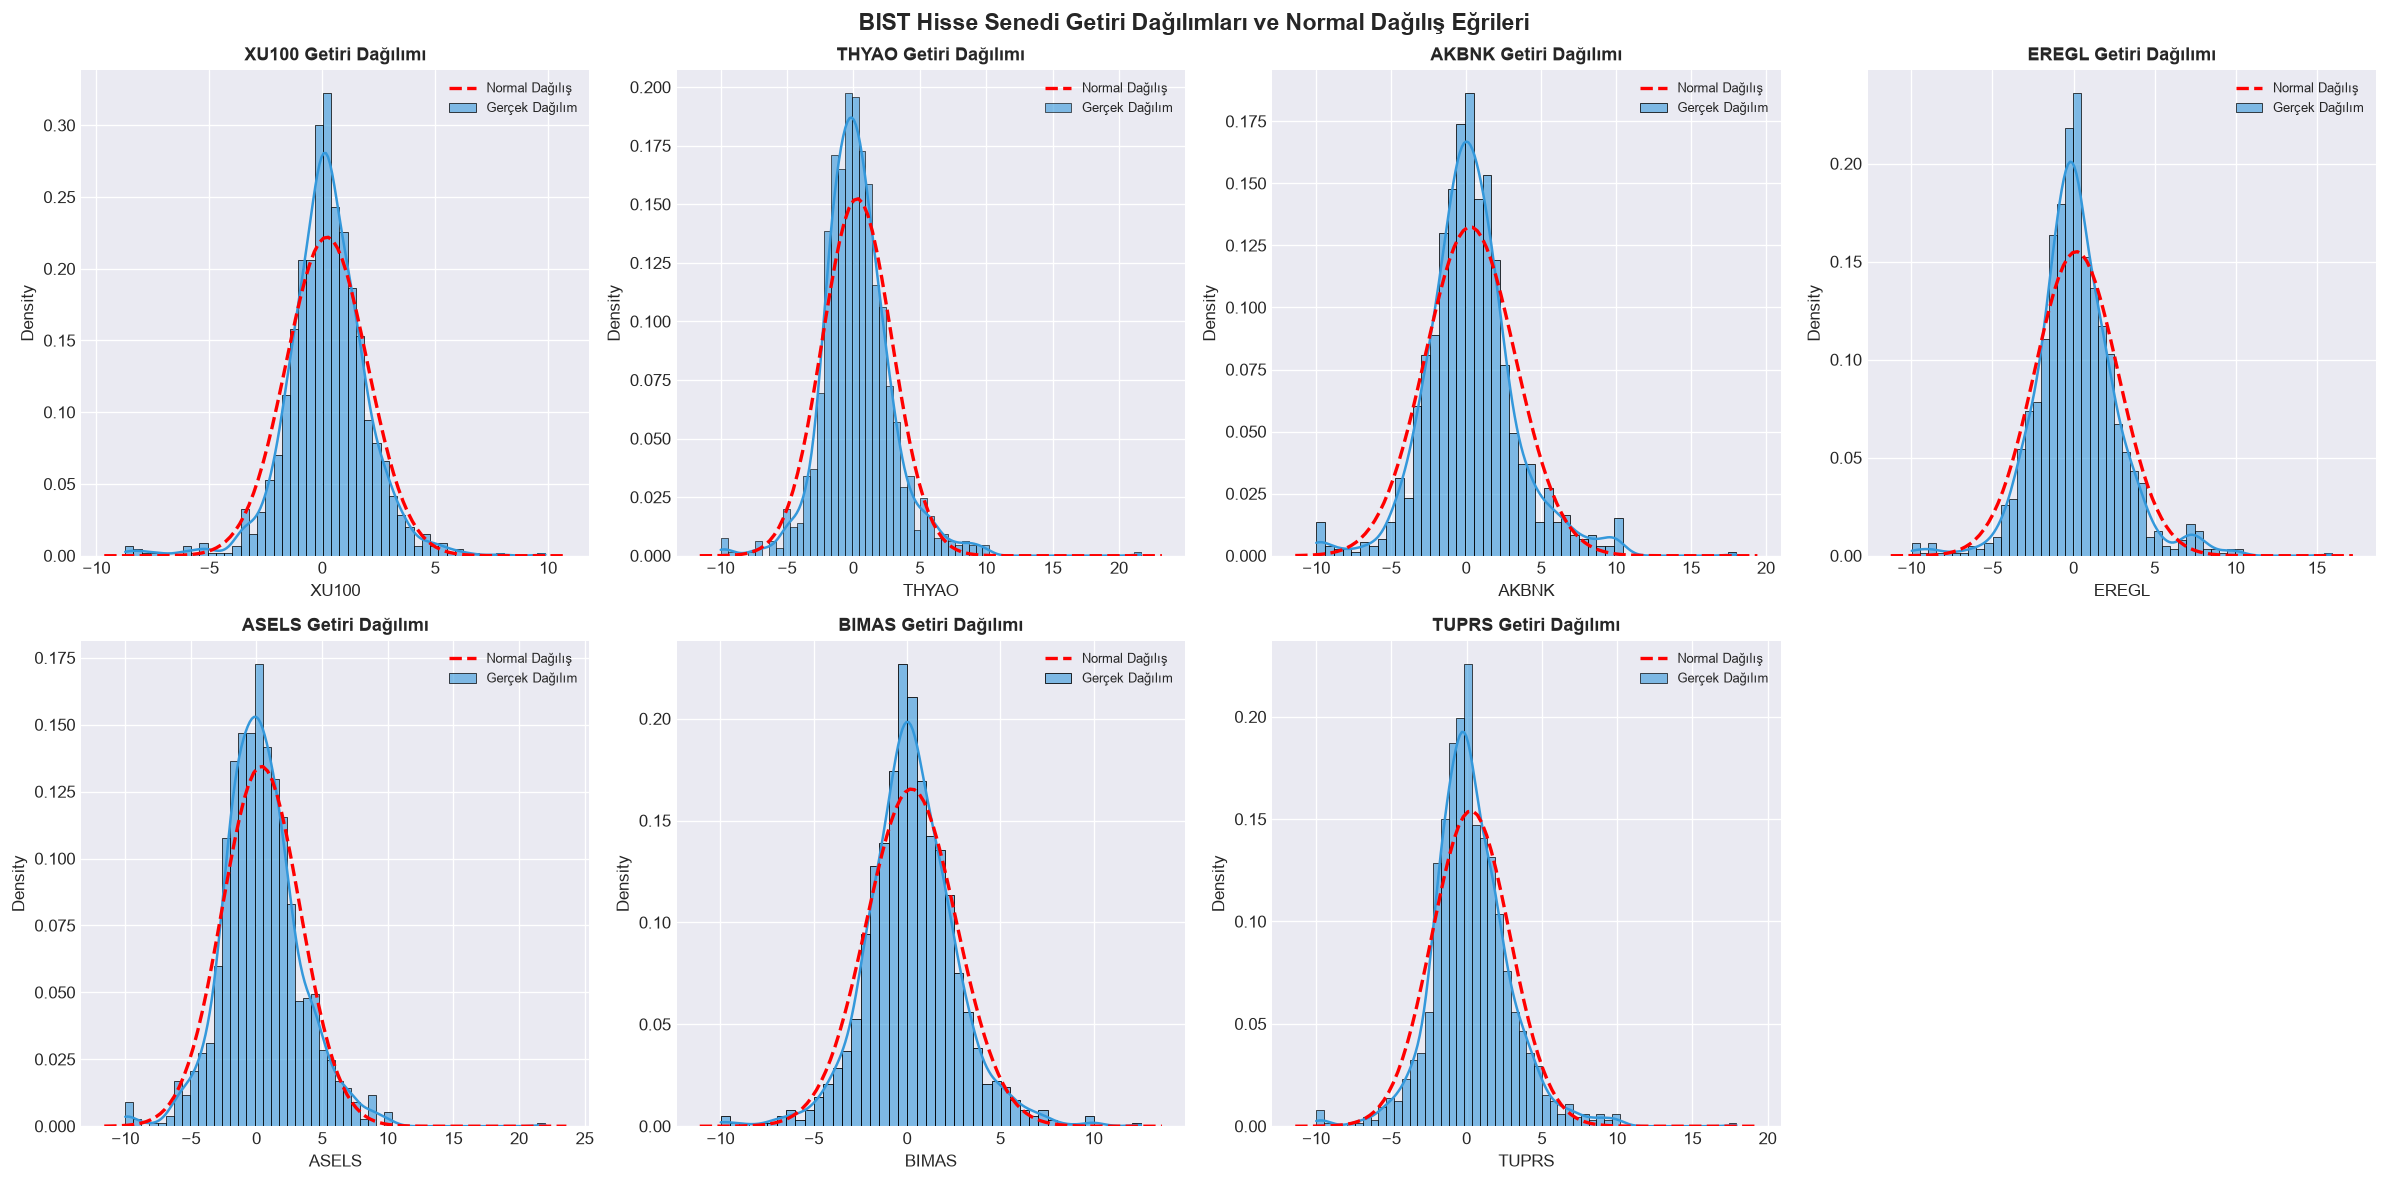

In [41]:
selected_assets = ['XU100', 'THYAO', 'AKBNK', 'EREGL', 'ASELS', 'BIMAS', 'TUPRS']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, asset in enumerate(selected_assets):
    ax = axes[i]
    data = daily_returns[asset].dropna()
    sns.histplot(data, kde=True, ax=ax, stat='density', color='#3498DB', alpha=0.6, label='Gerçek Dağılım')
    
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, 'r--', linewidth=2, label='Normal Dağılış')
    
    ax.set_title(f"{asset} Getiri Dağılımı", fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True)

axes[7].axis('off')
plt.suptitle('BIST Hisse Senedi Getiri Dağılımları ve Normal Dağılış Eğrileri', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../reports/getiri_dagilim_histogram_kde.png', bbox_inches='tight', dpi=300)
plt.show()

## 10. Sektörel Oynaklık ve Makro Şok Analizi (Araştırma Sorusu 2)

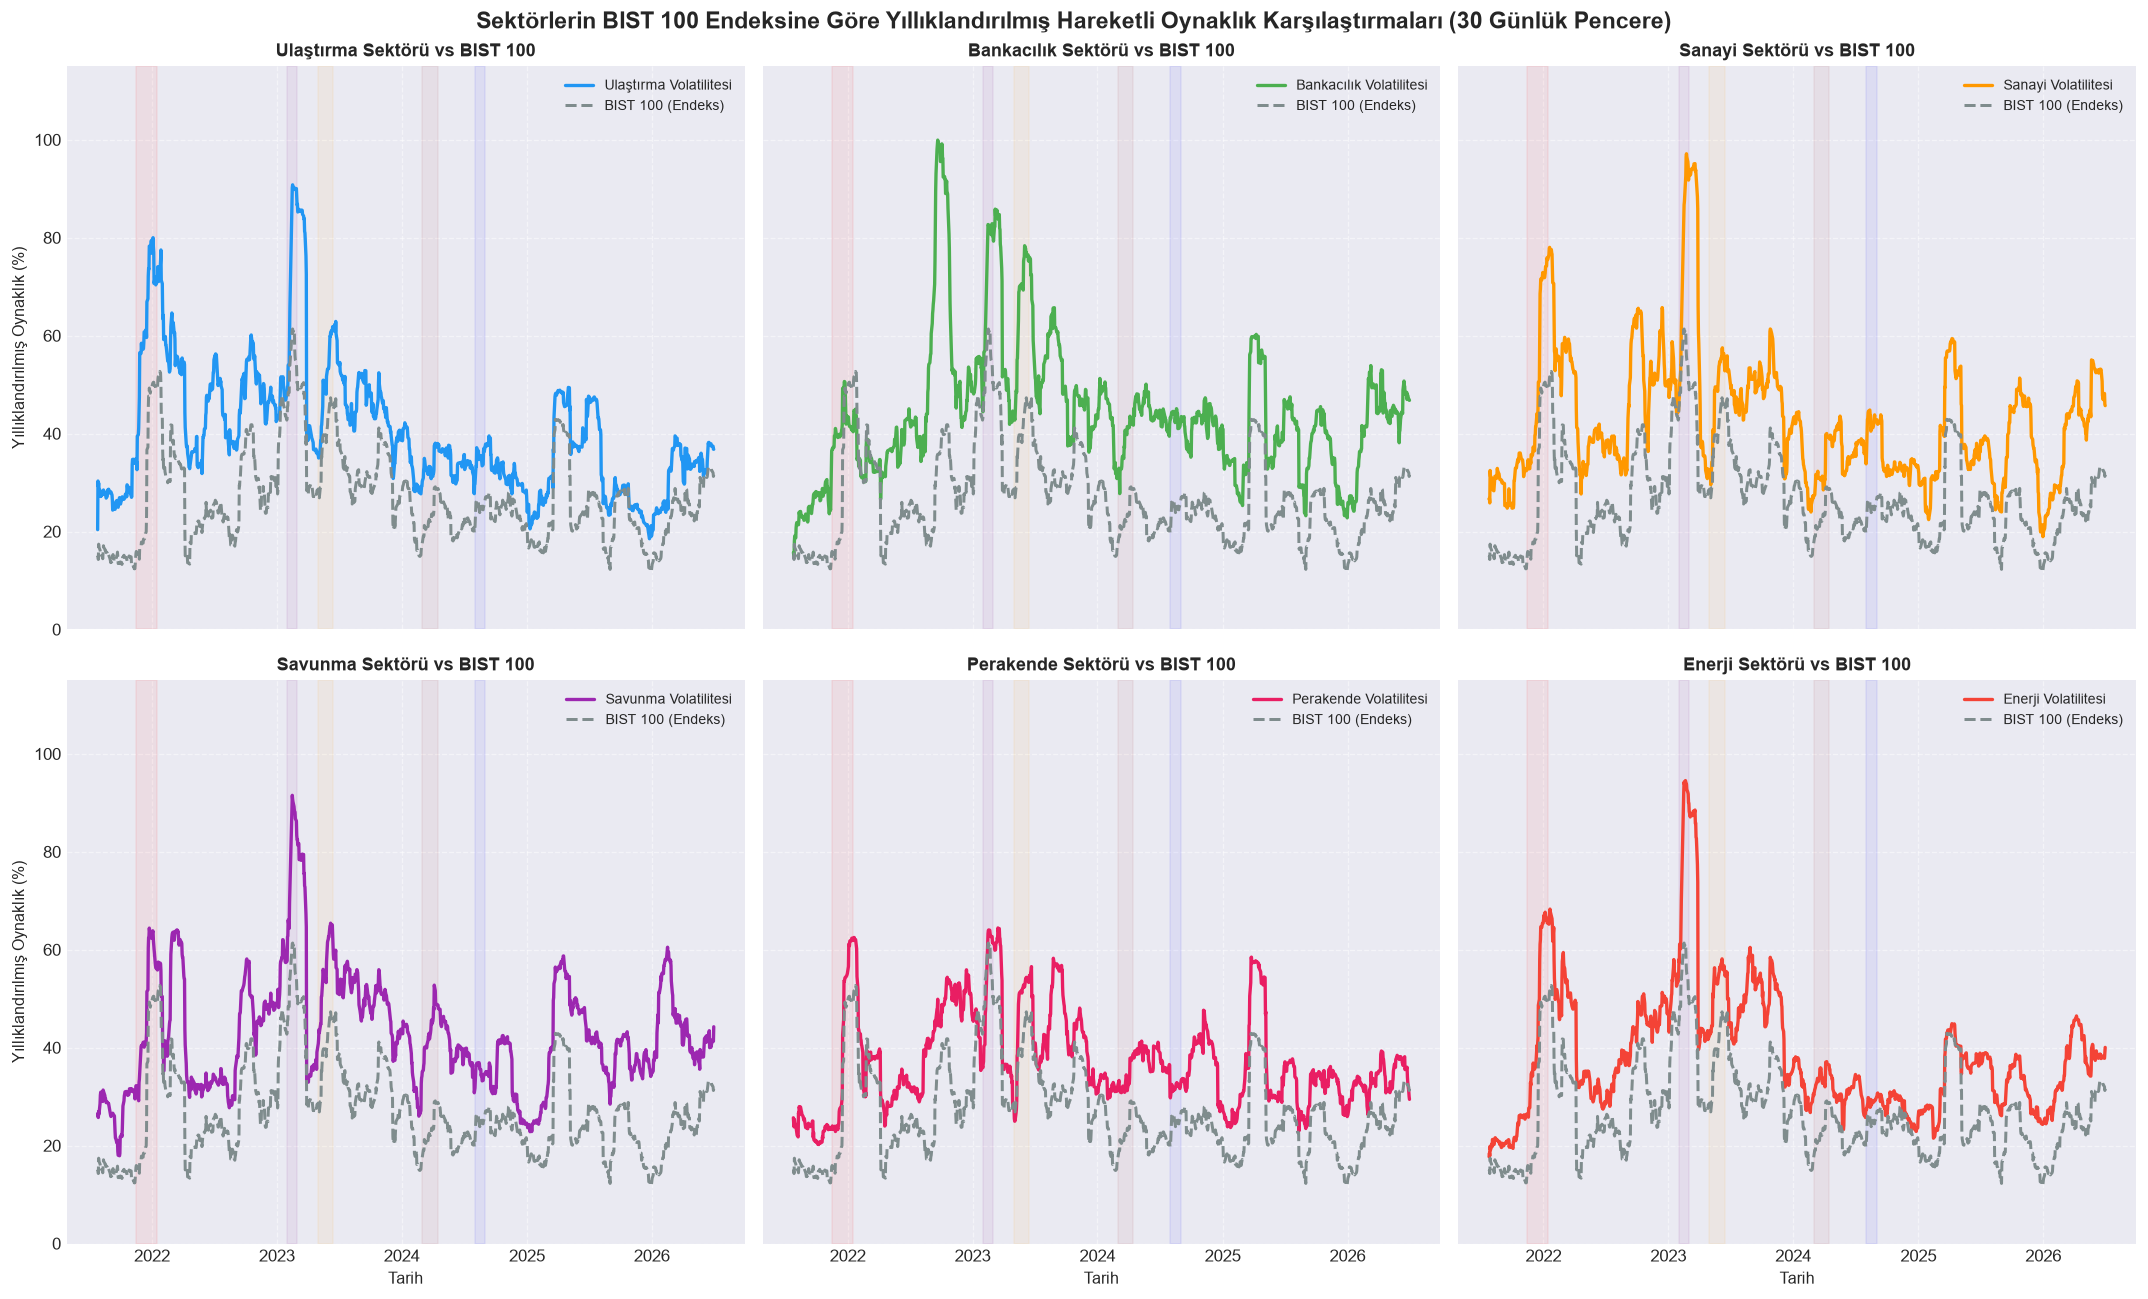

✅ Sektörel yıllık oynaklık subplot grafikleri başarıyla çizildi ve 'reports/sektorel_yillik_oynaklik.png' olarak kaydedildi.


In [42]:
rolling_vol_daily = daily_returns.rolling(window=30, min_periods=10).std()
rolling_vol_annual = rolling_vol_daily * np.sqrt(252)

sector_vols = pd.DataFrame(index=rolling_vol_annual.index)
for sector_name, assets in sectors_map.items():
    sector_vols[sector_name] = rolling_vol_annual[assets].mean(axis=1)
sector_vols['BIST 100'] = rolling_vol_annual['XU100']

# 2x3 Subplot Paneli Oluştur
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.flatten()

sectors_list = list(sectors_map.keys())

for i, sector in enumerate(sectors_list):
    ax = axes[i]
    color = colors[sector]
    
    # Sektör volatilitesi
    ax.plot(sector_vols.index, sector_vols[sector], label=f"{sector} Volatilitesi", color=color, linewidth=2.0)
    # BIST 100 volatilitesi
    ax.plot(sector_vols.index, sector_vols['BIST 100'], label="BIST 100 (Endeks)", color='#7F8C8D', linewidth=1.8, linestyle='--')
    
    # 5 Büyük Şok Dönemini İşaretle (Çok hafif opaklıkla)
    # 1. KKM Döviz Şoku
    ax.axvspan(pd.Timestamp('2021-11-15'), pd.Timestamp('2022-01-15'), color='red', alpha=0.06)
    # 2. Şubat 2023 Deprem
    ax.axvspan(pd.Timestamp('2023-02-01'), pd.Timestamp('2023-03-01'), color='purple', alpha=0.06)
    # 3. Mayıs 2023 Seçimler
    ax.axvspan(pd.Timestamp('2023-05-01'), pd.Timestamp('2023-06-15'), color='orange', alpha=0.06)
    # 4. Mart 2024 Faiz Artışı
    ax.axvspan(pd.Timestamp('2024-03-01'), pd.Timestamp('2024-04-15'), color='brown', alpha=0.06)
    # 5. Ağustos 2024 Küresel Satış
    ax.axvspan(pd.Timestamp('2024-08-01'), pd.Timestamp('2024-09-01'), color='blue', alpha=0.06)
    
    ax.set_title(f"{sector} Sektörü vs BIST 100", fontsize=11, fontweight='bold')
    ax.set_ylim(0, 115)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=8.5)
    
    if i >= 3:
        ax.set_xlabel('Tarih', fontsize=9.5)
    if i % 3 == 0:
        ax.set_ylabel('Yıllıklandırılmış Oynaklık (%)', fontsize=9.5)

# Grafiklerin üstüne genel başlık ekle
plt.suptitle('Sektörlerin BIST 100 Endeksine Göre Yıllıklandırılmış Hareketli Oynaklık Karşılaştırmaları (30 Günlük Pencere)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()

# Kaydet
plt.savefig('../reports/sektorel_yillik_oynaklik.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Sektörel yıllık oynaklık subplot grafikleri başarıyla çizildi ve 'reports/sektorel_yillik_oynaklik.png' olarak kaydedildi.")

## 11. Sektörel Teknik Göstergeler ve SMA Kesişimleri (EDA 4)

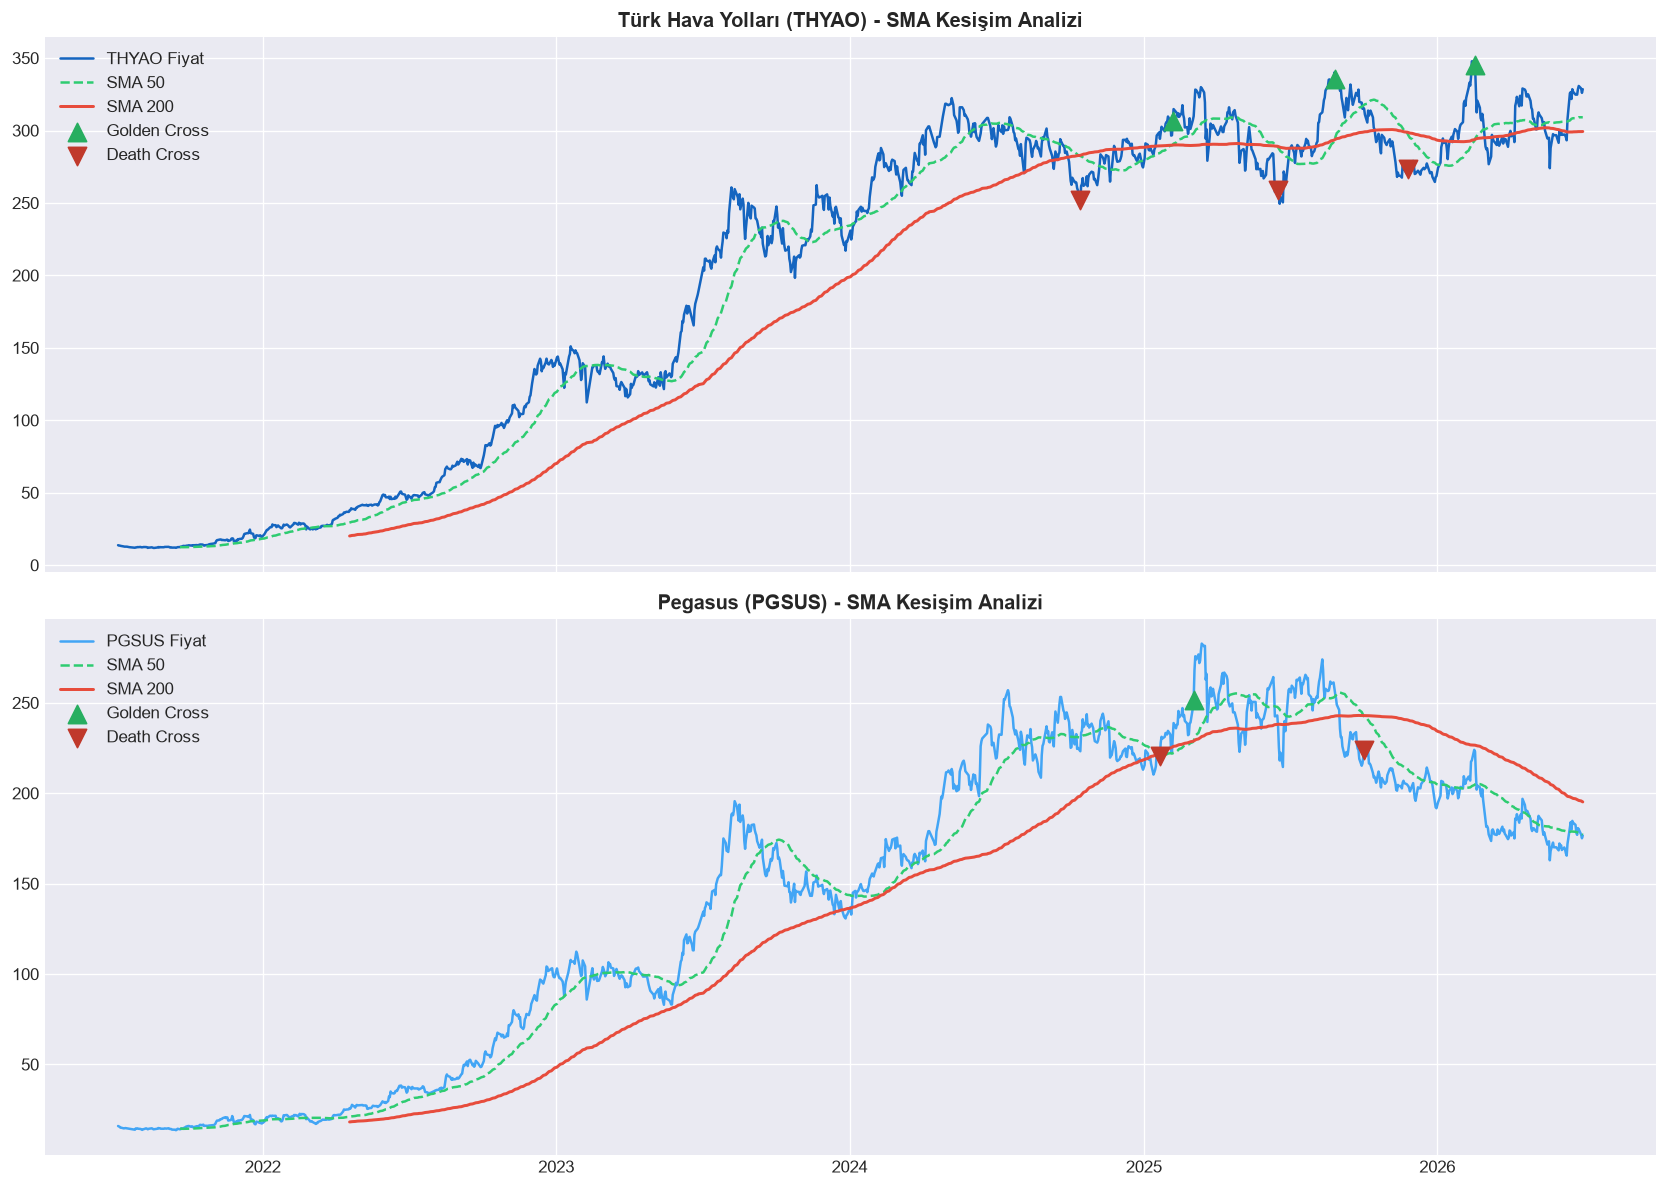

In [43]:
df_tech = adj_close_clean[['THYAO', 'PGSUS']].copy()
df_tech['THYAO_SMA50'] = df_tech['THYAO'].rolling(window=50).mean()
df_tech['THYAO_SMA200'] = df_tech['THYAO'].rolling(window=200).mean()
df_tech['PGSUS_SMA50'] = df_tech['PGSUS'].rolling(window=50).mean()
df_tech['PGSUS_SMA200'] = df_tech['PGSUS'].rolling(window=200).mean()

def find_crossovers(df, price_col, sma50_col, sma200_col):
    temp = df[[price_col, sma50_col, sma200_col]].dropna()
    temp['signal'] = np.where(temp[sma50_col] > temp[sma200_col], 1, 0)
    temp['crossover'] = temp['signal'].diff()
    golden = temp[temp['crossover'] == 1][[price_col]].rename(columns={price_col: 'Fiyat'})
    death = temp[temp['crossover'] == -1][[price_col]].rename(columns={price_col: 'Fiyat'})
    return golden, death

thyao_golden, thyao_death = find_crossovers(df_tech, 'THYAO', 'THYAO_SMA50', 'THYAO_SMA200')
pgsus_golden, pgsus_death = find_crossovers(df_tech, 'PGSUS', 'PGSUS_SMA50', 'PGSUS_SMA200')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Panel 1: THYAO
ax1.plot(df_tech.index, df_tech['THYAO'], label='THYAO Fiyat', color='#1565C0', linewidth=1.5)
ax1.plot(df_tech.index, df_tech['THYAO_SMA50'], label='SMA 50', color='#2ECC71', linewidth=1.5, linestyle='--')
ax1.plot(df_tech.index, df_tech['THYAO_SMA200'], label='SMA 200', color='#E74C3C', linewidth=1.8)
ax1.scatter(thyao_golden.index, thyao_golden['Fiyat'], color='#27AE60', marker='^', s=120, label='Golden Cross', zorder=5)
ax1.scatter(thyao_death.index, thyao_death['Fiyat'], color='#C0392B', marker='v', s=120, label='Death Cross', zorder=5)
ax1.set_title('Türk Hava Yolları (THYAO) - SMA Kesişim Analizi', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True)

# Panel 2: PGSUS
ax2.plot(df_tech.index, df_tech['PGSUS'], label='PGSUS Fiyat', color='#42A5F5', linewidth=1.5)
ax2.plot(df_tech.index, df_tech['PGSUS_SMA50'], label='SMA 50', color='#2ECC71', linewidth=1.5, linestyle='--')
ax2.plot(df_tech.index, df_tech['PGSUS_SMA200'], label='SMA 200', color='#E74C3C', linewidth=1.8)
ax2.scatter(pgsus_golden.index, pgsus_golden['Fiyat'], color='#27AE60', marker='^', s=120, label='Golden Cross', zorder=5)
ax2.scatter(pgsus_death.index, pgsus_death['Fiyat'], color='#C0392B', marker='v', s=120, label='Death Cross', zorder=5)
ax2.set_title('Pegasus (PGSUS) - SMA Kesişim Analizi', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.tight_layout()
plt.savefig('../reports/sektorel_teknik_gostergeler.png', bbox_inches='tight', dpi=300)
plt.show()

## 12. Fiyat/Hacim Korelasyonu ve Backtest Simülasyonu (Araştırma Sorusu 3)

✅ Fiyat/Hacim korelasyonları:


,Hacim-Mutlak Getiri Korelasyonu
BIMAS,0.416523
TUPRS,0.382553
MGROS,0.360885
AKBNK,0.335208
KRDMD,0.328778
ASELS,0.318232
ENJSA,0.309726
THYAO,0.301229
OTKAR,0.294044
PGSUS,0.287868


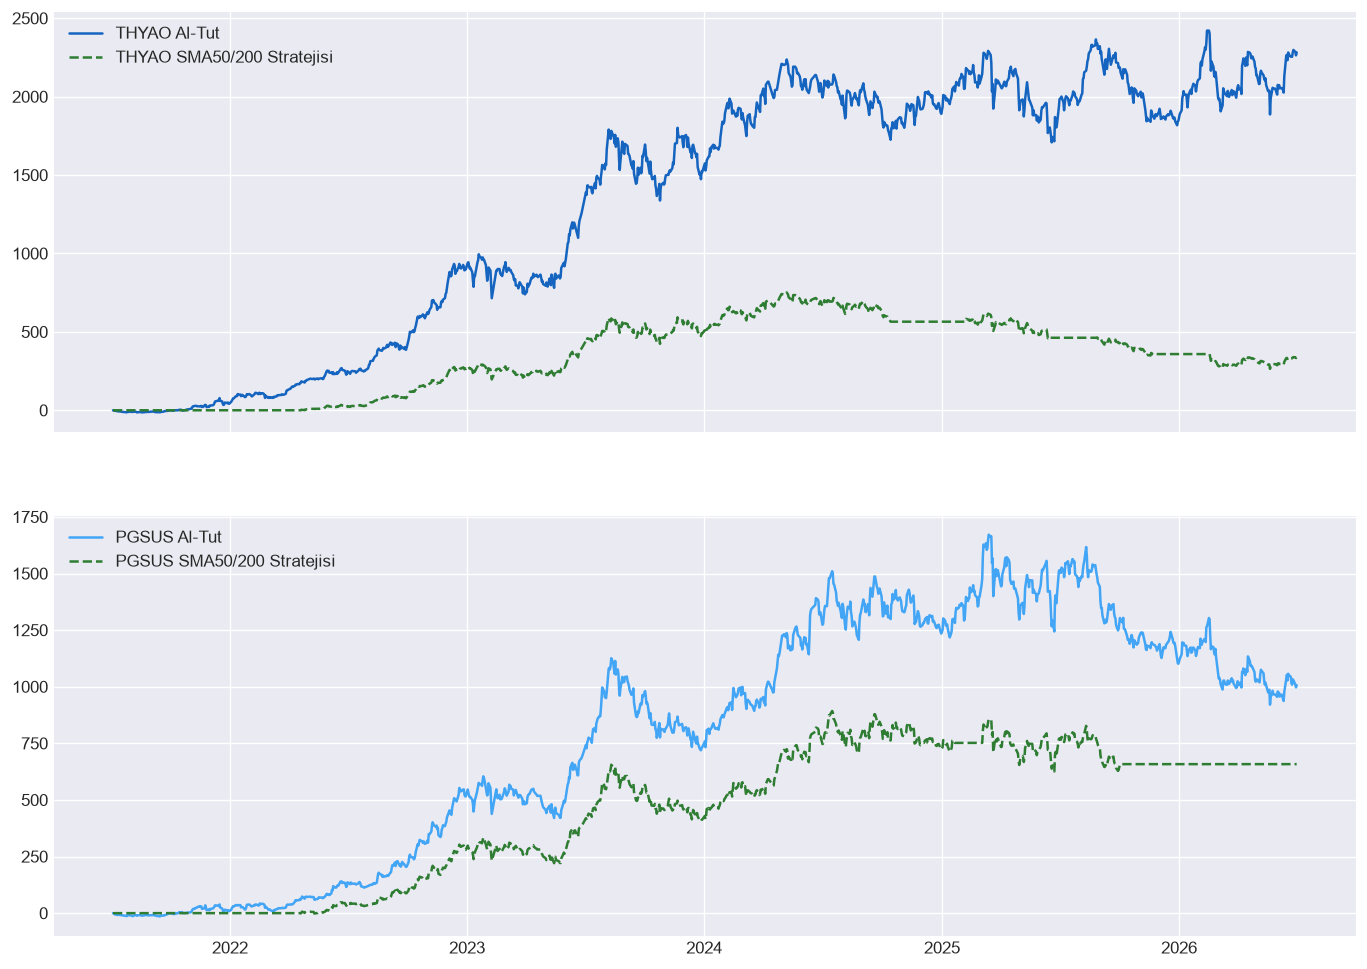

In [44]:
# Korelasyon katsayılarını hesapla
correlations = {}
for col in adj_close_clean.columns:
    df_temp = pd.DataFrame({'Abs_Return': daily_returns[col].abs(), 'Volume': volume_clean[col]}).dropna()
    correlations[col] = df_temp['Abs_Return'].corr(df_temp['Volume'])

corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Hacim-Mutlak Getiri Korelasyonu']).sort_values(by='Hacim-Mutlak Getiri Korelasyonu', ascending=False)
corr_df.to_csv('../data/processed/fiyat_hacim_korelasyonlari.csv')
print("✅ Fiyat/Hacim korelasyonları:")
display(corr_df)

# Backtest motoru
def run_sma_backtest(df_prices, ticket):
    df = pd.DataFrame(index=df_prices.index)
    df['Price'] = df_prices[ticket]
    df['Daily_Return'] = df['Price'].pct_change()
    df['SMA50'] = df['Price'].rolling(window=50).mean()
    df['SMA200'] = df['Price'].rolling(window=200).mean()
    
    df['Signal'] = np.where(df['SMA50'] > df['SMA200'], 1, 0)
    df['Position'] = df['Signal'].shift(1) # lookahead bias'ı engelle
    df['Strategy_Return'] = df['Position'] * df['Daily_Return']
    
    df['Buy_Hold_Cum'] = (1 + df['Daily_Return'].fillna(0)).cumprod() - 1
    df['Strategy_Cum'] = (1 + df['Strategy_Return'].fillna(0)).cumprod() - 1
    return df

thyao_backtest = run_sma_backtest(adj_close_clean, 'THYAO')
pgsus_backtest = run_sma_backtest(adj_close_clean, 'PGSUS')

# Kümülatif getirileri karşılaştır
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax1.plot(thyao_backtest.index, thyao_backtest['Buy_Hold_Cum'] * 100, label='THYAO Al-Tut', color='#1565C0')
ax1.plot(thyao_backtest.index, thyao_backtest['Strategy_Cum'] * 100, label='THYAO SMA50/200 Stratejisi', color='#2E7D32', linestyle='--')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.plot(pgsus_backtest.index, pgsus_backtest['Buy_Hold_Cum'] * 100, label='PGSUS Al-Tut', color='#42A5F5')
ax2.plot(pgsus_backtest.index, pgsus_backtest['Strategy_Cum'] * 100, label='PGSUS SMA50/200 Stratejisi', color='#2E7D32', linestyle='--')
ax2.legend(loc='upper left')
ax2.grid(True)

plt.savefig('../reports/backtest_kesisim_basarisi.png', bbox_inches='tight', dpi=300)
plt.show()

## 13. Sektörel Lineer Regresyon ve CAPM Modellemesi

Her hisse senedinin BIST 100 endeksi getirisine karşı CAPM lineer regresyon modeli Scikit-Learn ile kurularak saçılım grafiği (scatter plot) ve regresyon doğrusu çizdirilecektir.

,Hisse,Sektör,CAPM Alfası (Sabit),CAPM Betası (Eğim),R-squared (R2)
0,THYAO,Ulaştırma,0.067418,1.0853,0.5552
1,PGSUS,Ulaştırma,0.017195,1.0477,0.4697
2,AKBNK,Bankacılık,0.035458,1.1861,0.5007
3,GARAN,Bankacılık,0.071175,1.0270,0.4189
4,EREGL,Sanayi,-0.040320,1.0139,0.5018
5,KRDMD,Sanayi,-0.051352,1.2040,0.4903
6,ASELS,Savunma,0.146205,1.0409,0.3975
7,OTKAR,Savunma,0.021077,0.8278,0.3081
8,BIMAS,Perakende,0.061492,0.8598,0.4109
9,MGROS,Perakende,0.103461,0.8504,0.3799


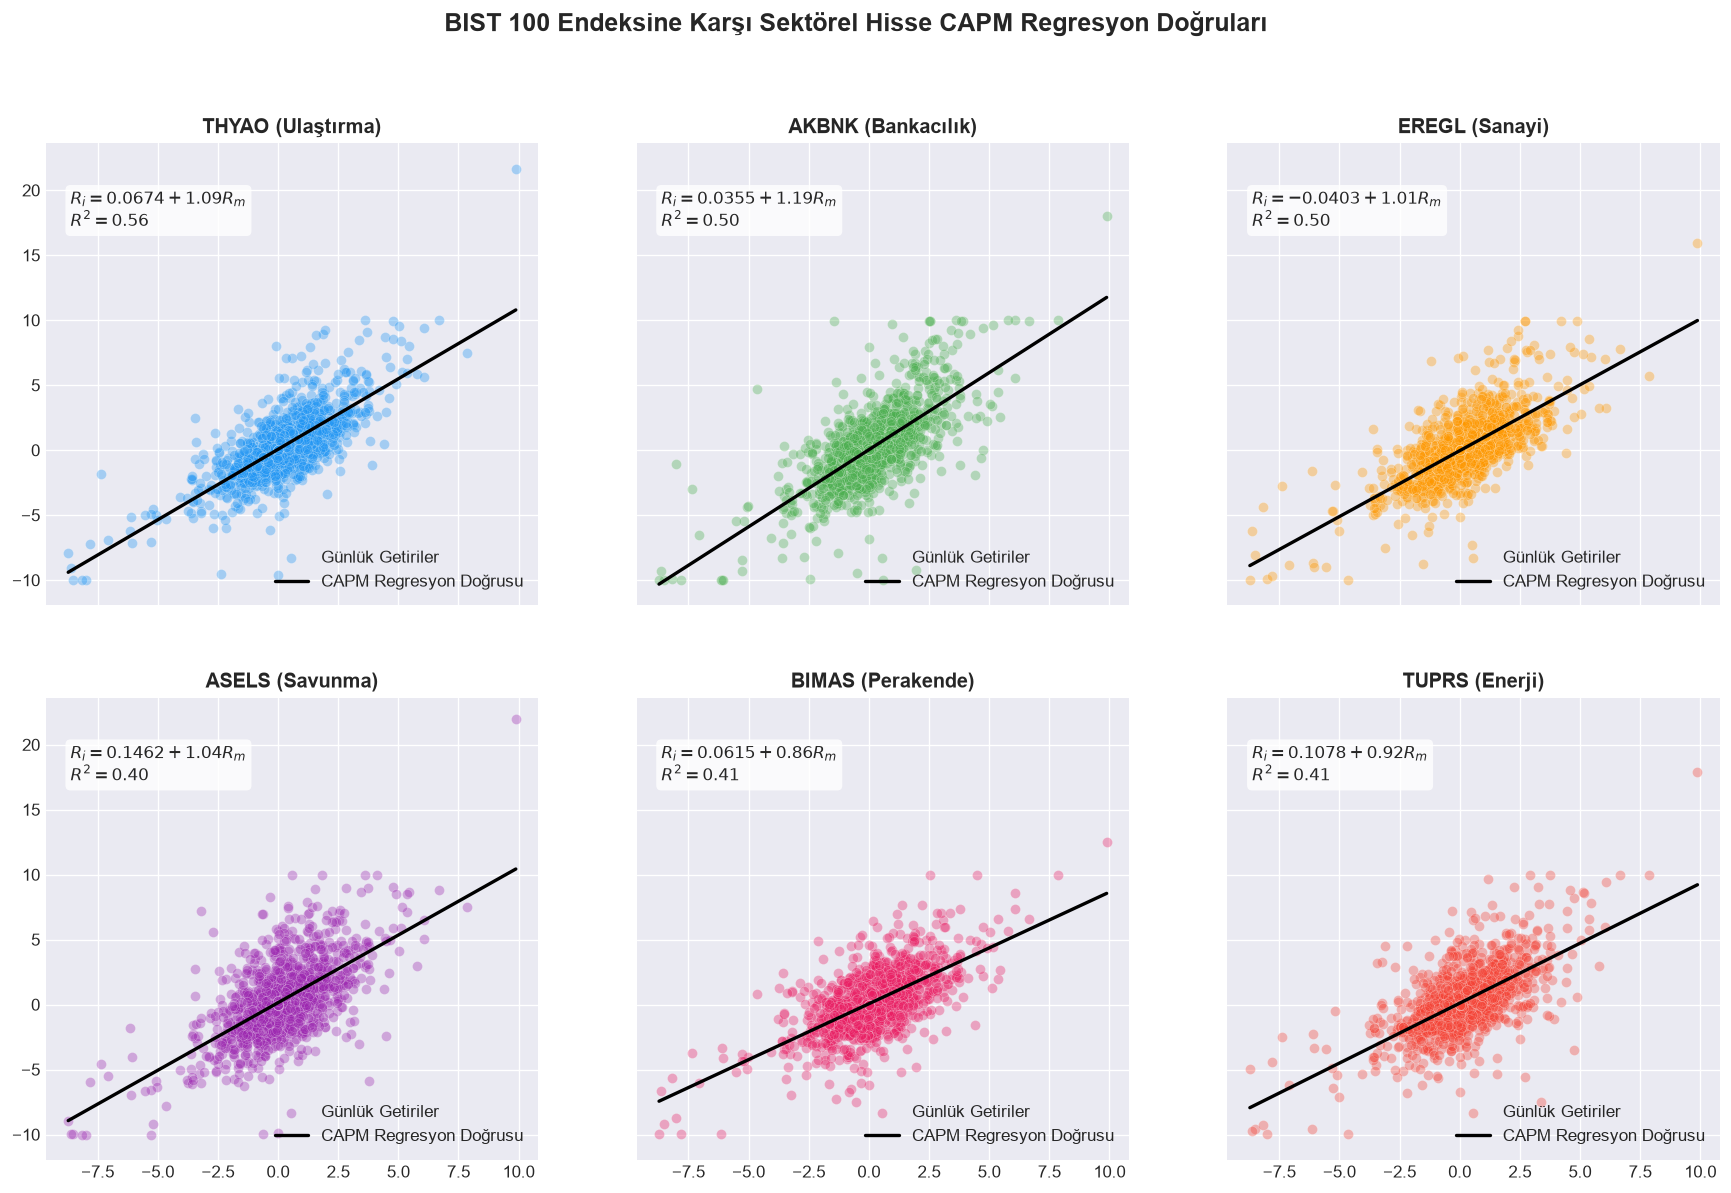

In [45]:
X = daily_returns[['XU100']].values
stocks = [col for col in daily_returns.columns if col != 'XU100']

capm_results = []
for stock in stocks:
    df_temp = daily_returns[[stock, 'XU100']].dropna()
    X_s = df_temp[['XU100']].values
    y_s = df_temp[stock].values
    
    model = LinearRegression()
    model.fit(X_s, y_s)
    
    beta = model.coef_[0]
    alfa = model.intercept_
    r2 = model.score(X_s, y_s)
    
    capm_results.append({
        'Hisse': stock,
        'Sektör': hisse_sektor[stock],
        'CAPM Alfası (Sabit)': round(alfa, 6),
        'CAPM Betası (Eğim)': round(beta, 4),
        'R-squared (R2)': round(r2, 4)
    })

capm_df = pd.DataFrame(capm_results)
capm_df.to_csv('../data/processed/capm_regresyon_sonuclari.csv', index=False)
display(capm_df)

# Temsili 6 Hissenin Saçılım Doğruları Grafiği
representative_stocks = ['THYAO', 'AKBNK', 'EREGL', 'ASELS', 'BIMAS', 'TUPRS']
colors_map = {
    'THYAO': '#2196F3', 'AKBNK': '#4CAF50', 'EREGL': '#FF9800',
    'ASELS': '#9C27B0', 'BIMAS': '#E91E63', 'TUPRS': '#F44336'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True, sharey=True)
axes = axes.flatten()

for i, stock in enumerate(representative_stocks):
    ax = axes[i]
    color = colors_map[stock]
    
    df_temp = daily_returns[[stock, 'XU100']].dropna()
    X_val = df_temp['XU100'].values
    y_val = df_temp[stock].values
    
    row = capm_df[capm_df['Hisse'] == stock].iloc[0]
    alfa = row['CAPM Alfası (Sabit)']
    beta = row['CAPM Betası (Eğim)']
    r2 = row['R-squared (R2)']
    
    ax.scatter(X_val, y_val, color=color, alpha=0.35, edgecolors='white', linewidths=0.3, label='Günlük Getiriler')
    
    x_range = np.linspace(X_val.min(), X_val.max(), 100)
    y_pred = alfa + beta * x_range
    ax.plot(x_range, y_pred, color='black', linewidth=2.0, label='CAPM Regresyon Doğrusu')
    
    eq_text = f"$R_i = {alfa:.4f} + {beta:.2f} R_m$\n$R^2 = {r2:.2f}$"
    ax.text(0.05, 0.82, eq_text, transform=ax.transAxes, fontsize=10, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3'))
    
    ax.set_title(f"{stock} ({row['Sektör']})", fontsize=12, fontweight='bold')
    ax.legend(loc='lower right')
    ax.grid(True)

plt.suptitle('BIST 100 Endeksine Karşı Sektörel Hisse CAPM Regresyon Doğruları', fontsize=15, fontweight='bold', y=0.98)
plt.savefig('../reports/sektorel_capm_regresyon.png', bbox_inches='tight', dpi=300)
plt.show()